In [1]:
import slangpy as spy
from itertools import islice
from pyglm import glm
import torch
import torchvision
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt

from cs248a_renderer import setup_device, RendererModules
from cs248a_renderer.renderer.core_renderer import Renderer
from cs248a_renderer.model.volumes import DenseVolume
from cs248a_renderer.model.transforms import Transform3D

from cs231nfinal.camera import RandomCameraTransform
from cs231nfinal.tvnorm import tv_image_loss_isotropic, tv_volume_loss_isotropic
from cs231nfinal.style import NaiveStylizer

%load_ext autoreload
%autoreload 2

device = setup_device([])
renderer_modules = RendererModules(device)

[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
# OUTPUT_IMG_SIZE = (800, 800)
PROCESS_IMG_SIZE = (200, 200)
PREVIEW_IMG_SIZE = (500, 500)

# create framebuffers
output_image = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=PROCESS_IMG_SIZE[0],
    height=PROCESS_IMG_SIZE[1],
)

output_preview = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_float,
    usage=spy.TextureUsage.unordered_access,
    width=PREVIEW_IMG_SIZE[0],
    height=PREVIEW_IMG_SIZE[1],
)

# Setup the renderer
renderer = Renderer(
    device=device,
    render_texture=output_image,
    render_modules=renderer_modules
)
renderer.sqrt_spp = 1
renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

preview_renderer = Renderer(
    device=device,
    render_texture=output_preview,
    render_modules=renderer_modules
)
preview_renderer.sqrt_spp = 1
preview_renderer._ambientColor = glm.vec4(1.0, 1.0, 1.0, 1.0)

In [3]:
from cs231nfinal.data import DatasetID, DataSet
import numpy as np
from openvdb import FloatGrid

dataset = DataSet.Get(DatasetID.SMOKE_LOWRES)

data_array = np.zeros(dataset.resolution)
grid = dataset.get_grid("density", frame=70, type=FloatGrid)

grid.copyToArray(data_array, ijk=grid.evalLeafBoundingBox()[0])
min, max = grid.evalMinMax()

# normalize data
data_array = 0.5 * ((data_array + min) / (max - min))

CAMERA_DIST = 23
VOLUME_POS = glm.vec3(0,2.8,3.5)

In [4]:
def make_dense_volume(volume_tensor) -> DenseVolume:
    return DenseVolume(
        name="volume",
        transform=Transform3D(position=VOLUME_POS),
        data=volume_tensor.detach().numpy().astype(np.float32),
        properties={
            "pivot": (0.5, 0.5, 0.5),
            "voxel_size": dataset.voxel_size,
        },
    )

def show_preview(dense_volume, cam_mat, fov):
    preview_renderer.load_volume(volume=dense_volume)
    preview_renderer.render(cam_mat, fov)
    preview_res = np.flipud(output_preview.to_numpy().copy())
    plt.imshow(preview_res, cmap="gray")
    plt.axis("off")
    plt.show()

In [10]:
params = {
    "num_epochs": 80,
    "num_views": 8,
    "learning_rate": 5e-3,
    # "tv_weight_2d": 0,
    "tv_weight_3d": 0.0000,
    "cam_kappa": 100,
    "cam_fov": 40,
}


stylizer = NaiveStylizer(PROCESS_IMG_SIZE, "data/style/good_ones/dark_matter_bw.png")

Epochs:   0%|          | 0/80 [00:00<?, ?it/s]

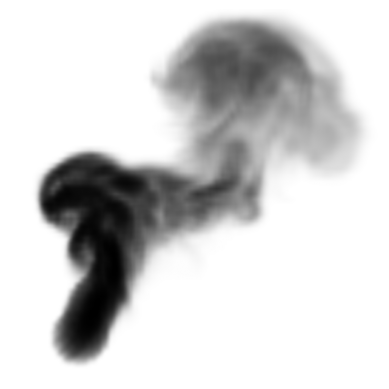

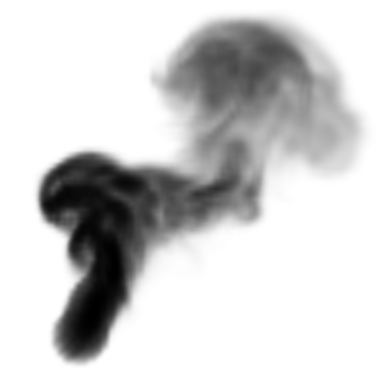

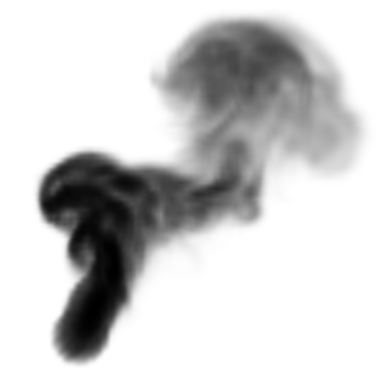

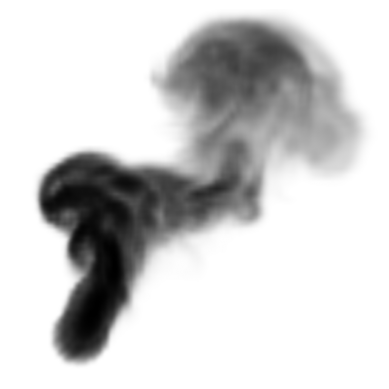

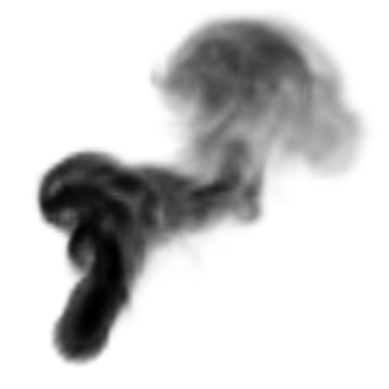

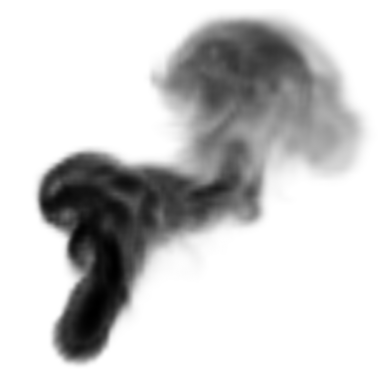

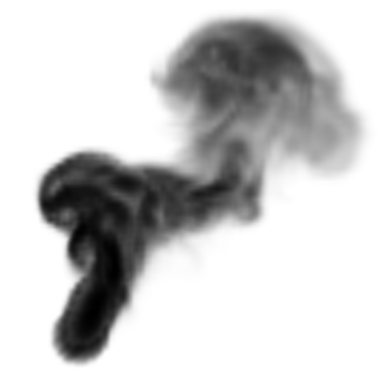

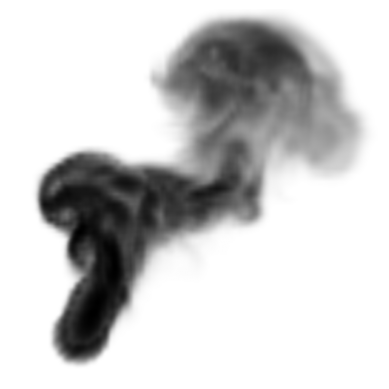

In [ ]:
cam_transform = RandomCameraTransform(CAMERA_DIST, kappa=params["cam_kappa"])
canonical_cam = next(RandomCameraTransform(CAMERA_DIST, kappa=np.inf))

input_tensor = torch.tensor(data_array.astype(np.float32), requires_grad=False)
input_density_total = input_tensor.sum()

batch_losses = []

density_gain = torch.ones_like(input_tensor, requires_grad=True)

optim = torch.optim.Adam([density_gain], lr=params["learning_rate"])
scheduler = torch.optim.lr_scheduler.ExponentialLR(optim, 0.99)

for epoch in tqdm(range(params["num_epochs"]), desc="Epochs"):
    optim.zero_grad()

    scaled_input = input_tensor * density_gain
    # preserve density
    density_normalized_input = scaled_input * (input_density_total / scaled_input.sum())
    dense_volume = make_dense_volume(density_normalized_input)

    renderer.load_volume(volume=dense_volume)

    if (epoch % 10) == 0:
        show_preview(dense_volume, canonical_cam, params["cam_fov"])


    volume_renders = []
    view_mats = list(islice(cam_transform, params["num_views"]))
    for i in range(params["num_views"]):
        renderer.render(view_mats[i], params["cam_fov"])
        volume_render = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)

        volume_renders.append(volume_render)
    
    render_stack = torch.stack(volume_renders)
    render_stack.retain_grad()
    loss_fn = torch.nn.MSELoss()
    tv_loss = params["tv_weight_3d"] * tv_volume_loss_isotropic(density_normalized_input)
    loss = loss_fn(render_stack, stylizer.style(render_stack)) + tv_loss
    batch_loss = loss.item()

    loss.backward()

    gain_acc = np.zeros(input_tensor.shape).astype(np.float32)
    for i in range(params["num_views"]):
        renderer.render_volume_backward(
            view_mat=view_mats[i], 
            fov=params["cam_fov"], 
            out_grad=torch.flipud(render_stack.grad[i])
        )
        d_volume = renderer.get_d_volume().reshape(input_tensor.shape)
        gain_acc += d_volume
    
    with torch.no_grad():
        ## grad == gain_acc / num_views
        #  input_tensor + grad == input_tensor * (density_gain + gain_update)
        #  1 + grad / input_tensor == density_gain + gain_update
        #  gain_update == 1 - density_gain + grad / input_tensor

        gain_update = 1 - density_gain + torch.tensor(gain_acc) / (params["num_views"] * input_tensor)
        density_gain.grad = density_gain.grad + gain_update

    
    optim.step()

    with torch.no_grad():
        density_gain.clamp_(0, 100)
    
    batch_losses.append(batch_loss)

    scheduler.step()



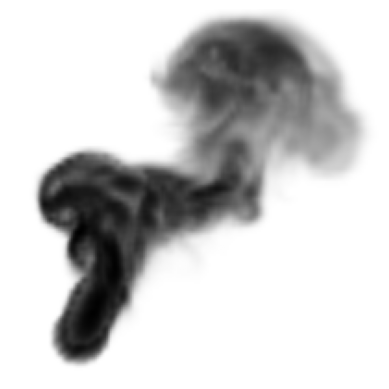

In [12]:
renderer.render(canonical_cam, params["cam_fov"])

volume_render = torch.tensor(np.flipud(output_image.to_numpy()).copy(), requires_grad=True)
plt.imshow(volume_render.detach().numpy(), cmap="gray")
plt.axis("off")
plt.show()

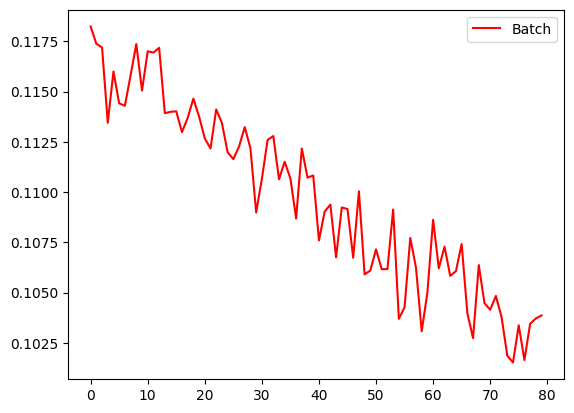

In [13]:
x = range(params["num_epochs"])
plt.plot(x, batch_losses, label="Batch", color="red")
# plt.yscale("log")
plt.legend()
plt.show()

In [9]:
from openvdb import FloatGrid
from openvdb import write as write_vdb

test_out_grid = FloatGrid()
test_out_grid.name = "density"

test_out_np = (density_normalized_input).detach().numpy()
test_out_grid.copyFromArray(test_out_np)
write_vdb('test_out4.vdb', grids=[test_out_grid])